# From ECG to HR and simple HRV (Principles: vagal tone, RSA)

## TODOs

1. Compute RMSSD and HF power during baseline vs stress masks. 
2. Describe which increases/decreases and why (vagal withdrawal during stress → lower RMSSD/HF).

## My notes

+ RMSSD (Root Mean Square of Successive Differences)
    - Calculate using the R-peaks, where these R-peaks are the heartbeats.
    - R-peaks come from ECG, where ECG has P-wave, QRS-complex, and T-wave.
    - Time domain.
    - Steps:
        1. From the ECG, detect the components: P-wave, QRS-complex, and T-wave. 
        2. Delineate ECG for R-peaks, where these R-peaks are the heartbeats
        3. Calculate RMSSD by passing in R-peaks to get HRV
            - 3.1 1 R-peak = 1 Heartbeat
            - 3.2 Consecutive R-peaks are RR-interval = consecutive HBs
                - 3.2.1  From RR-interval, calculate LF/HF
    - We want this value to be
        1. high bc it leads to better recovery + more ANS stimulaton?
            - high means more time between heartbeats
        2. varied bc it leads to better recovery
+ HF (High Frequency) power
    1. Frequency domain.
    2. Favors parasympathetic activity, which is rest and recovery/digest.
    3. We want this value to be high bc...

## Code

In [1]:
import os
import pickle

import numpy as np
import pandas as pd

import neurokit2 as nk

import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.signal import find_peaks, welch
from adtk.data import validate_series
from adtk.detector import ThresholdAD

In [2]:
def load_wesad_subject(pkl_path: str):
    """Return dict with 'signal', 'label', plus any metadata present."""
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')  # WESAD often needs latin1
    # Normalize a few expected top-level keys if available
    out = {'raw': data}
    # Try common patterns
    for k in ['signal', 'signals', 'data']:
        if k in data:
            out['signal'] = data[k]
            break
    if 'label' in data:
        out['label'] = data['label']
    elif 'labels' in data:
        out['label'] = data['labels']
    return out

def summarize_structure(s):
    print("Top-level keys:", list(s['raw'].keys()))
    sig = s.get('signal', {})
    print("Signal namespaces:", list(sig.keys()))
    for ns, v in sig.items():
        if isinstance(v, dict):
            print(f"  [{ns}] channels:", list(v.keys()))
            for ch, arr in v.items():
                try:
                    print(f"    - {ch}: shape={np.array(arr).shape}, dtype={np.array(arr).dtype}")
                except Exception:
                    print(f"    - {ch}: (non-array)")
    if 'label' in s:
        lab = np.array(s['label']).squeeze()
        print("Labels shape:", lab.shape, "| unique:", np.unique(lab))

In [3]:
path_to_pkl = '../../../roeh-health/data/WESAD/per_subject/S7/S7.pkl'
S = load_wesad_subject(path_to_pkl)
summarize_structure(S)

Top-level keys: ['signal', 'label', 'subject']
Signal namespaces: ['chest', 'wrist']
  [chest] channels: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
    - ACC: shape=(3666600, 3), dtype=float64
    - ECG: shape=(3666600, 1), dtype=float64
    - EMG: shape=(3666600, 1), dtype=float64
    - EDA: shape=(3666600, 1), dtype=float64
    - Temp: shape=(3666600, 1), dtype=float32
    - Resp: shape=(3666600, 1), dtype=float64
  [wrist] channels: ['ACC', 'BVP', 'EDA', 'TEMP']
    - ACC: shape=(167616, 3), dtype=float64
    - BVP: shape=(335232, 1), dtype=float64
    - EDA: shape=(20952, 1), dtype=float64
    - TEMP: shape=(20952, 1), dtype=float64
Labels shape: (3666600,) | unique: [0 1 2 3 4 5 6 7]


In [4]:
S

{'raw': {'signal': {'chest': {'ACC': array([[ 1.06960011, -0.014     ,  1.4612    ],
           [ 1.06539989, -0.01020002,  1.42219996],
           [ 1.06539989,  0.00419998,  1.32019997],
           ...,
           [ 0.84660006, -0.10820001, -0.05739999],
           [ 0.84220004, -0.11379999, -0.08139998],
           [ 0.83340001, -0.11519998, -0.10259998]], shape=(3666600, 3)),
    'ECG': array([[-0.01922607],
           [-0.01693726],
           [-0.01615906],
           ...,
           [ 0.08638   ],
           [ 0.13993835],
           [ 0.23899841]], shape=(3666600, 1)),
    'EMG': array([[-0.04884338],
           [-0.00700378],
           [ 0.07177734],
           ...,
           [ 0.19976807],
           [ 0.22764587],
           [ 0.21807861]], shape=(3666600, 1)),
    'EDA': array([[12.50686646],
           [12.46871948],
           [12.50686646],
           ...,
           [13.09013367],
           [13.08135986],
           [13.08021545]], shape=(3666600, 1)),
    'Temp': ar

In [5]:
def rr_from_ecg(ecg, fs, min_rr=0.3, max_rr=2.0):
    """Very simple R-peak detection + RR intervals (seconds)."""
    x = (ecg - np.median(ecg)) / (np.std(ecg) + 1e-9)
    peak_idxs, _ = find_peaks(x, distance=int(min_rr*fs), prominence=np.std(x)*0.5)
    rr = np.diff(peak_idxs) / fs
    rr = rr[(rr > min_rr) & (rr < max_rr)]
    return peak_idxs, rr

In [6]:
def hrv_time(rr):
    """Basic time-domain HRV: SDNN, RMSSD, pNN50."""
    rr_ms = rr * 1000.0
    sdnn = np.std(rr_ms, ddof=1)
    diff = np.diff(rr_ms)
    rmssd = np.sqrt(np.mean(diff**2))
    pnn50 = np.mean(np.abs(diff) > 50.0) * 100.0
    return {'SDNN_ms': sdnn, 'RMSSD_ms': rmssd, 'pNN50_%': pnn50}


In [7]:
def hrv_freq(rr, fs_interp=4.0):
    """Welch PSD on interpolated tachogram → LF/HF power."""
    t = np.cumsum(rr)
    t = t - t[0]
    f = interp1d(t, rr, kind='linear', fill_value="extrapolate")
    t_even = np.arange(0, t[-1], 1.0/fs_interp)
    rr_even = f(t_even)
    rr_even = (rr_even - np.mean(rr_even))
    fxx, pxx = welch(rr_even, fs=fs_interp, nperseg=min(256, len(rr_even)))
    
    def band_power(fb):
        idx = np.logical_and(fxx >= fb[0], fxx < fb[1])
        return np.trapz(pxx[idx], fxx[idx])
    
    lf = band_power((0.04, 0.15))
    hf = band_power((0.15, 0.40))
    return {'LF': lf, 'HF': hf, 'LF_HF': (lf / hf) if hf > 0 else np.nan}

In [8]:
def detect_anomaly(peak_times, peak_amplitudes):
    """
    Detect anomalies in peak amplitudes using ADTK ThresholdAD.
    
    Parameters
    ----------
    peak_times : array_like
        Times of detected peaks in seconds.
    peak_amplitudes : array_like
        Amplitudes of detected peaks.
    
    Returns
    -------
    anomolies : pd.Series
        Boolean series indicating anomalies.
    anomaly_mask : np.ndarray
        Boolean array mask for anomalies.
    anomaly_times : np.ndarray
        Times of anomalous peaks.
    anomaly_amplitudes : np.ndarray
        Amplitudes of anomalous peaks.
    low_threshold : float
        Lower threshold value.
    high_threshold : float
        Upper threshold value.
    """
    # Convert to pandas Series with DateTimeIndex for ADTK
    peak_series = pd.Series(
        peak_amplitudes,
        index=pd.to_datetime(peak_times, unit='s', origin='unix')
    )
    
    # Statistical approach
    mean_amp = np.mean(peak_amplitudes)
    std_amp = np.std(peak_amplitudes)
    low_threshold = mean_amp - 3*std_amp
    high_threshold = mean_amp + 3*std_amp
    
    anomoly_detector = ThresholdAD(low=low_threshold, high=high_threshold)
    anomolies = anomoly_detector.detect(peak_series)
    
    # Get anomaly indices and values
    anomaly_mask = anomolies.values
    anomaly_times = peak_times[anomaly_mask]
    anomaly_amplitudes = peak_amplitudes[anomaly_mask]
    
    return anomolies, anomaly_mask, anomaly_times, anomaly_amplitudes, low_threshold, high_threshold

In [9]:



def plot_ecg_segment(ecg, peak_idxs, fs_ecg, segment_idx, segment_duration=10):
    """
    Plot a single ECG segment with detected R-peaks and anomalies.
    
    Parameters
    ----------
    ecg : array_like
        The ECG signal data.
    peak_idxs : array_like
        Indices of detected R-peaks.
    fs_ecg : float
        Sampling frequency of the ECG signal.
    segment_idx : int
        Index of the segment to plot (0-based).
    segment_duration : int, optional
        Duration of each segment in seconds (default is 10).
    
    Returns
    -------
    None
    """
    t_ecg = np.arange(len(ecg)) / fs_ecg
    
    start_idx = segment_idx * int(segment_duration * fs_ecg)
    end_idx = (segment_idx + 1) * int(segment_duration * fs_ecg)
    
    # Ensure we don't exceed the signal length
    if start_idx >= len(ecg):
        print(f"Segment {segment_idx + 1} exceeds signal length")
        return
    end_idx = min(end_idx, len(ecg))
    
    # Get the segment
    t_segment = t_ecg[start_idx:end_idx]
    ecg_segment = ecg[start_idx:end_idx]
    
    # Get peaks within this segment
    pk_segment = peak_idxs[(peak_idxs >= start_idx) & (peak_idxs < end_idx)]
    
    # Extract peak information
    peak_times = t_ecg[pk_segment]
    peak_amplitudes = ecg[pk_segment]
    
    # Detect anomalies
    anomolies, anomaly_mask, anomaly_times, anomaly_amplitudes, low_threshold, high_threshold = detect_anomaly(
        peak_times=peak_times, 
        peak_amplitudes=peak_amplitudes
    )
    
    # Separate normal and anomalous peaks
    normal_mask = ~anomaly_mask
    normal_times = peak_times[normal_mask]
    normal_amplitudes = peak_amplitudes[normal_mask]
    
    # Print peak information
    print(f"\n=== Segment {segment_idx + 1} Peak Information ===")
    print(f"\tPeak Amplitudes: {peak_amplitudes}")
    print(f"\tNumber of peaks in segment: {len(pk_segment)}")
    print(f"\tMean amplitude: {np.mean(peak_amplitudes):.4f}")
    print(f"\tStd amplitude: {np.std(peak_amplitudes):.4f}")
    print(f"\tThresholds: [{low_threshold:.4f}, {high_threshold:.4f}]")
    print(f"\tMin amplitude: {np.min(peak_amplitudes):.4f}")
    print(f"\tMax amplitude: {np.max(peak_amplitudes):.4f}")
    print(f"\tNumber of anomalies: {np.sum(anomaly_mask)}")
    if np.sum(anomaly_mask) > 0:
        print(f"\tAnomaly amplitudes: {anomaly_amplitudes}")
        print(f"\tAnomaly times (s): {anomaly_times}")
    
    # Plot
    plt.figure(figsize=(12, 3))
    plt.plot(t_segment, ecg_segment, lw=0.7, label='ECG signal', color='blue')
    
    # Plot normal peaks in green
    if len(normal_times) > 0:
        plt.plot(normal_times, normal_amplitudes, 'go', ms=5, label=f'Normal R-peaks ({len(normal_times)})')
    
    # Plot anomalies in red with larger markers
    if len(anomaly_times) > 0:
        plt.plot(anomaly_times, anomaly_amplitudes, 'ro', ms=8, label=f'Anomalous peaks ({len(anomaly_times)})', 
                markeredgewidth=1.5, markeredgecolor='darkred')
    
    # Add threshold lines
    plt.axhline(y=low_threshold, color='orange', linestyle='--', alpha=0.7, linewidth=1.5, 
                label=f'Low threshold ({low_threshold:.2f})')
    plt.axhline(y=high_threshold, color='orange', linestyle='--', alpha=0.7, linewidth=1.5, 
                label=f'High threshold ({high_threshold:.2f})')
    
    # Annotate first few peaks with their amplitudes
    for i, (t, amp) in enumerate(zip(peak_times[:5], peak_amplitudes[:5])):
        plt.annotate(f'{amp:.3f}', xy=(t, amp), xytext=(0, 10), 
                    textcoords='offset points', ha='center', fontsize=8)
    
    plt.title(f"ECG segment {segment_idx + 1} (seconds {segment_idx*segment_duration} to {(segment_idx+1)*segment_duration})")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print()
    print()

In [10]:
# --- pick ECG from chest or BVP from wrist as proxy if ECG missing ---
sig = S.get('signal', {})
ecg = None; fs_ecg = None

# Heuristic channel search
for ns in ['chest', 'wrist']:
    if ns in sig:
        for ch in sig[ns]:
            name = ch.lower()
            if 'ecg' in name:
                ecg = np.asarray(sig[ns][ch]).squeeze()
                fs_ecg = 700.0  # Use correct sampling rate from WESAD
                source = f"{ns}:{ch}"
                break
    if ecg is not None:
        break

Detected 6398 R-peaks from chest:ECG. RR count=6360

Time-domain HRV: {'SDNN_ms': np.float64(187.07516562539766), 'RMSSD_ms': np.float64(136.0521448171799), 'pNN50_%': np.float64(38.76395659694921)}

Freq-domain HRV: {'LF': np.float64(0.004501608364704172), 'HF': np.float64(0.003036357620010774), 'LF_HF': np.float64(1.4825685667053272)}

=== Segment 1 Peak Information ===
	Peak Amplitudes: [0.49369812 1.4992218  1.49908447 1.45143127 1.47843933 1.4992218
 1.46479797 1.46626282 1.48374939 1.44818115 1.45880127 1.49217224
 1.49913025 1.46507263 1.46983337 1.48677063 1.49180603 1.45710754
 1.46626282 1.48118591 1.46328735 1.45573425 1.46868896 1.48310852
 1.46141052 1.46983337 1.45198059 1.47496033 1.47981262 1.4523468
 1.47674561 1.47747803 1.46955872 1.46575928 1.47953796 1.46955872
 1.45504761 1.4622345  1.47784424 1.4655304  1.45916748 1.47271729
 1.47221375 1.44850159 1.46287537 1.47605896 1.46781921 1.47651672
 1.45664978 1.46406555 1.4839325  1.48603821 1.46369934 1.49482727
 1.458

/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_28730/885799439.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(pxx[idx], fxx[idx])


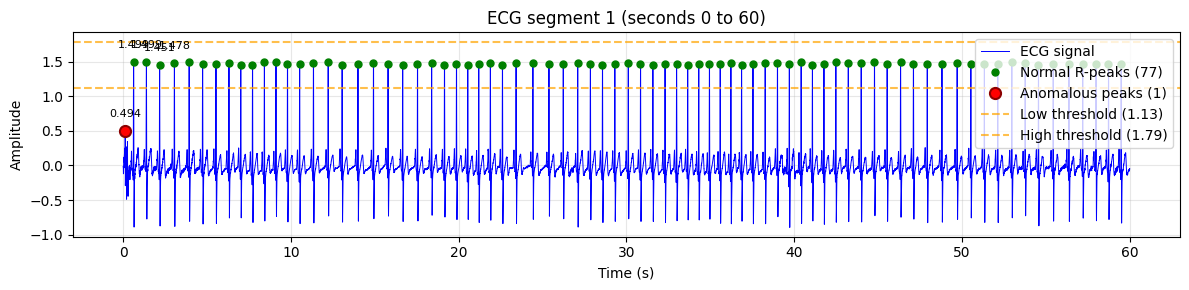

In [11]:
if ecg is not None:
    peaks, rr = rr_from_ecg(ecg, fs_ecg)
    print(f"Detected {len(peaks)} R-peaks from {source}. RR count={len(rr)}\n")
    print(f"Time-domain HRV: {hrv_time(rr)}\n")
    print(f"Freq-domain HRV: {hrv_freq(rr)}")
    
    # Plot each segment separately
    plot_ecg_segment(ecg, peaks, fs_ecg, segment_idx=0, segment_duration=60)
else:
    print("No ECG channel found.")

> - There exists one anomaly, the first R-peak detected. Assumption is that this is "normal" or always happen?
> - Low threshold is value i from the standard deviation and High threshold is value j from the standard deviation
> - Standard deviation is the distance from the mean $\newline$
    - Low = close to mean, less variability/spread $\newline$
    - High = far from mean, more variability/spread

- Would we want a high standard deviation, which in turn leads to a lower valued low threshold and a higher valued high threshold? This would indicate more variability of the R-Peaks. 

Detected 6398 R-peaks from chest:ECG. RR count=6360

Time-domain HRV: {'SDNN_ms': np.float64(187.07516562539766), 'RMSSD_ms': np.float64(136.0521448171799), 'pNN50_%': np.float64(38.76395659694921)}

Freq-domain HRV: {'LF': np.float64(0.004501608364704172), 'HF': np.float64(0.003036357620010774), 'LF_HF': np.float64(1.4825685667053272)}

=== Segment 2 Peak Information ===
	Peak Amplitudes: [1.47839355 1.49803162 1.49034119 1.48603821 1.48530579 1.46543884
 1.467453   1.47798157 1.49647522 1.4790802  1.48008728 1.45692444
 1.48127747 1.47532654 1.49871826 1.46626282 1.47358704 1.48384094
 1.49217224 1.46759033 1.46543884 1.48091125 1.48191833 1.4992218
 1.49913025 1.49913025 1.49784851 1.48558044 1.47184753 1.49684143
 1.48118591 0.02947998 1.48127747 1.4672699  1.47853088 1.47486877
 1.48439026 1.47477722 1.46781921 1.4992218  1.49913025 1.49620056
 1.46763611 1.48045349 1.48548889 1.46534729 1.49446106 1.49913025
 1.47450256 1.46342468 1.45536804 1.47322083 1.47679138 1.49665833
 1.48

/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_28730/885799439.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(pxx[idx], fxx[idx])


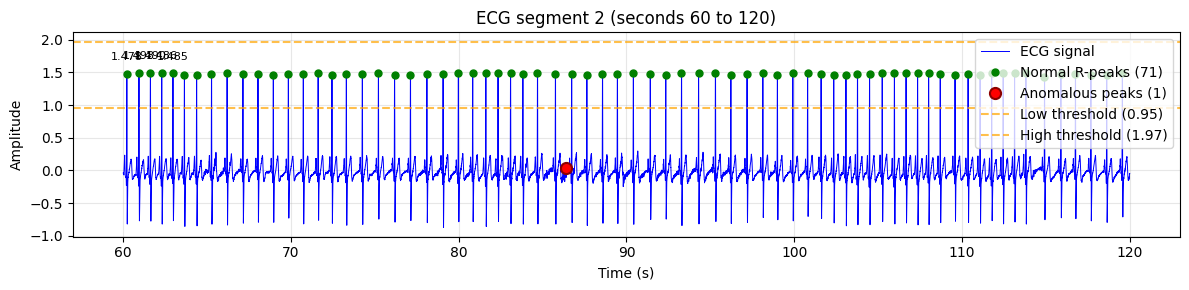

In [12]:
if ecg is not None:
    peaks, rr = rr_from_ecg(ecg, fs_ecg)
    print(f"Detected {len(peaks)} R-peaks from {source}. RR count={len(rr)}\n")
    print(f"Time-domain HRV: {hrv_time(rr)}\n")
    print(f"Freq-domain HRV: {hrv_freq(rr)}")
    
    # Plot each segment separately
    plot_ecg_segment(ecg, peaks, fs_ecg, segment_idx=1, segment_duration=60)
else:
    print("No ECG channel found.")

> There exists one R-peak anomaly bc it falls outside of the low threshold value. 

Detected 6398 R-peaks from chest:ECG. RR count=6360

Time-domain HRV: {'SDNN_ms': np.float64(187.07516562539766), 'RMSSD_ms': np.float64(136.0521448171799), 'pNN50_%': np.float64(38.76395659694921)}

Freq-domain HRV: {'LF': np.float64(0.004501608364704172), 'HF': np.float64(0.003036357620010774), 'LF_HF': np.float64(1.4825685667053272)}

=== Segment 3 Peak Information ===
	Peak Amplitudes: [1.48265076 1.47093201 1.46406555 1.47015381 1.49913025 1.47285461
 1.45463562 1.47203064 1.4992218  1.48164368 1.45417786 1.45353699
 1.45930481 1.49473572 1.4598999  1.44122314 1.47312927 1.49913025
 1.4992218  1.46195984 1.41682434 1.43701172 1.45298767 1.45637512
 1.46864319 1.46104431 1.46662903 1.48310852 1.48370361 1.44163513
 1.44026184 1.46003723 1.45500183 1.48443604 1.43760681 1.43943787
 1.46104431 1.48118591 1.44941711 1.45994568 1.47019958 1.4800415
 1.47816467 1.46429443 1.42497253 1.4606781  1.4697876  1.46864319
 1.4730835  1.43412781 1.4992218  1.48924255 1.48200989 1.4724884
 1.479

/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_28730/885799439.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(pxx[idx], fxx[idx])


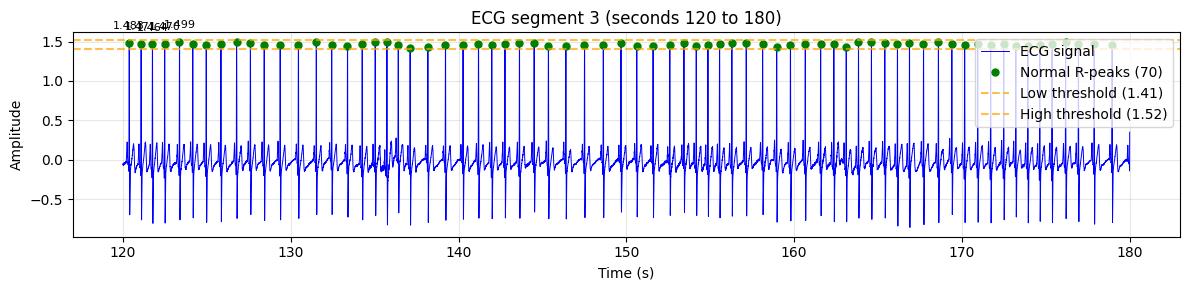

In [13]:
if ecg is not None:
    peaks, rr = rr_from_ecg(ecg, fs_ecg)
    print(f"Detected {len(peaks)} R-peaks from {source}. RR count={len(rr)}\n")
    print(f"Time-domain HRV: {hrv_time(rr)}\n")
    print(f"Freq-domain HRV: {hrv_freq(rr)}")
    
    # Plot each segment separately
    plot_ecg_segment(ecg, peaks, fs_ecg, segment_idx=2, segment_duration=60)
else:
    print("No ECG channel found.")

> There exist no anomalies because all values fall within the low and high thresholds. 

> - With the code above, I see that the image or the figure is showing roughly 10 seconds. Are we saying that the entirety of this subject's data is 10 seconds, or we sample only 10 seconds from this subject's data? If the letter of sample is only 10 seconds, then how can I sample another 10 seconds? I don't fully understand the code given to me. Base your comments direct on my statements and questions line by line.

## Follow-Up

> - Be sure to see TODOs

1. What do we gather from this subject?
2. Is there anything to flag?
3. 'RMSSD_ms': np.float64(698.4470516017469)
    - Why?
    - Good/Bad?
4. 'HF': np.float64(0.04114562090390898), why?
    - Why?
    - Good/Bad?
5. RMSSD_ms and HF considered jointly
    - If one is good and other bad? Vice versa
    - If both are good? Both are bad?

### 1. What do we gather from this subject?

> - R-peaks (aka heartbeats in green).
